In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("01_numpy_dstats.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Timestamp'] = df['Timestamp'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
df.drop(columns=["Container", "ID", "PIDs"], inplace=True)

In [3]:
df.head(3)

,Timestamp,Name,CPUPerc,MemUsage,MemPerc,NetIO,BlockIO
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00%,14.68MiB / 20MiB,73.40%,988B / 0B,0B / 0B
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08%,92.16MiB / 15.48GiB,0.58%,1.34kB / 0B,0B / 0B
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17%,98.49MiB / 15.48GiB,0.62%,82.4MB / 519kB,0B / 0B


In [4]:
# MemUsage, NetIO, lockIO 분리
df[["MemUsed", "MemTotal"]] = df["MemUsage"].str.split(" / ", expand=True)
df[["NetIn", "NetOut"]] = df["NetIO"].str.split(" / ", expand=True)
df[["BlockIn", "BlockOut"]] = df["BlockIO"].str.split(" / ", expand=True)
df.drop(columns=["MemUsage", "NetIO", "BlockIO"], inplace=True)
df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00%,73.40%,14.68MiB,20MiB,988B,0B,0B,0B
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08%,0.58%,92.16MiB,15.48GiB,1.34kB,0B,0B,0B
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17%,0.62%,98.49MiB,15.48GiB,82.4MB,519kB,0B,0B


In [5]:
df["CPUPerc"] = df["CPUPerc"].str.rstrip("%").astype(float)
df["MemPerc"] = df["MemPerc"].str.rstrip("%").astype(float)
df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00,73.40,14.68MiB,20MiB,988B,0B,0B,0B
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08,0.58,92.16MiB,15.48GiB,1.34kB,0B,0B,0B
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17,0.62,98.49MiB,15.48GiB,82.4MB,519kB,0B,0B


In [6]:
print(df.head(3).to_csv(index=False))

Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.0,73.4,14.68MiB,20MiB,988B,0B,0B,0B
2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08,0.58,92.16MiB,15.48GiB,1.34kB,0B,0B,0B
2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17,0.62,98.49MiB,15.48GiB,82.4MB,519kB,0B,0B



In [7]:
# 단위 변환 함수
def convert_memory(value):
    """메모리를 MiB 단위로 변환"""
    match = re.match(r"([\d\.]+)([A-Za-z]+)", str(value))
    if match:
        num, unit = float(match.group(1)), match.group(2)
        if unit == "GiB":  # Gibibyte → Mebibyte
            return round(num * 1024, 2)
        elif unit == "MiB":  # Mebibyte 그대로 유지
            return num
    return float(value)  # 이미 숫자인 경우 그대로 반환

def convert_network(value):
    """네트워크와 블록 IO를 MB 단위로 변환"""
    match = re.match(r"([\d\.]+)([A-Za-z]+)", str(value))
    if match:
        num, unit = float(match.group(1)), match.group(2)
        if unit == "GB":  # Gigabyte → Megabyte
            return round(num * 1024, 2)
        elif unit == "MB":  # Megabyte 그대로 유지
            return num
        elif unit == "kB":  # Kilobyte → Megabyte
            return round(num * 0.001, 6)
        elif unit == "B":  # Byte → Megabyte
            return round(num * 0.000001, 6)
    return float(value)  # 이미 숫자인 경우 그대로 반환

In [8]:
df['MemUsed'] = df['MemUsed'].apply(convert_memory).astype(float)
df['MemTotal'] = df['MemTotal'].apply(convert_memory).astype(float)

In [9]:
network_cols = ["NetIn", "NetOut", "BlockIn", "BlockOut"]

for col in network_cols:
    df[col] = df[col].apply(convert_network).astype(float)

df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,reverse-proxy-cache-1,0.00,73.40,14.68,20.00,0.000988,0.000,0.0,0.0
1,2025-02-28 16:10:40+09:00,reverse-proxy-lb-1,0.08,0.58,92.16,15851.52,0.001340,0.000,0.0,0.0
2,2025-02-28 16:10:40+09:00,reverse-proxy-agent-1,1.17,0.62,98.49,15851.52,82.400000,0.519,0.0,0.0


In [10]:
df['Name'] = df['Name'].str.split('-').str[2].str.upper()
df.head(3)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
0,2025-02-28 16:10:40+09:00,CACHE,0.00,73.40,14.68,20.00,0.000988,0.000,0.0,0.0
1,2025-02-28 16:10:40+09:00,LB,0.08,0.58,92.16,15851.52,0.001340,0.000,0.0,0.0
2,2025-02-28 16:10:40+09:00,AGENT,1.17,0.62,98.49,15851.52,82.400000,0.519,0.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype                     
---  ------     --------------  -----                     
 0   Timestamp  745 non-null    datetime64[ns, Asia/Seoul]
 1   Name       745 non-null    object                    
 2   CPUPerc    745 non-null    float64                   
 3   MemPerc    745 non-null    float64                   
 4   MemUsed    745 non-null    float64                   
 5   MemTotal   745 non-null    float64                   
 6   NetIn      745 non-null    float64                   
 7   NetOut     745 non-null    float64                   
 8   BlockIn    745 non-null    float64                   
 9   BlockOut   745 non-null    float64                   
dtypes: datetime64[ns, Asia/Seoul](1), float64(8), object(1)
memory usage: 58.3+ KB


In [12]:
df.describe()

,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
count,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.0,745.0
mean,11.516886,27.686201,512.814523,9566.112000,89.750195,90.639921,0.0,0.0
std,30.361271,29.762791,1022.983890,7703.554867,85.548946,77.416768,0.0,0.0
min,0.000000,0.580000,13.580000,20.000000,0.000988,0.000000,0.0,0.0
25%,0.080000,1.460000,96.650000,256.000000,5.000000,7.010000,0.0,0.0
50%,0.100000,5.700000,128.300000,15851.520000,83.300000,84.600000,0.0,0.0
75%,1.450000,67.760000,680.100000,15851.520000,196.000000,137.000000,0.0,0.0
max,174.210000,73.400000,5389.310000,15851.520000,213.000000,245.000000,0.0,0.0


In [13]:
print(df.head(5).to_csv(index=False))

Timestamp,Name,CPUPerc,MemPerc,MemUsed,MemTotal,NetIn,NetOut,BlockIn,BlockOut
2025-02-28 16:10:40+09:00,CACHE,0.0,73.4,14.68,20.0,0.000988,0.0,0.0,0.0
2025-02-28 16:10:40+09:00,LB,0.08,0.58,92.16,15851.52,0.00134,0.0,0.0,0.0
2025-02-28 16:10:40+09:00,AGENT,1.17,0.62,98.49,15851.52,82.4,0.519,0.0,0.0
2025-02-28 16:10:40+09:00,API,0.1,20.04,51.3,256.0,0.00145,0.0,0.0,0.0
2025-02-28 16:10:40+09:00,CONTROLLER,1.81,5.16,817.7,15851.52,0.52,82.4,0.0,0.0



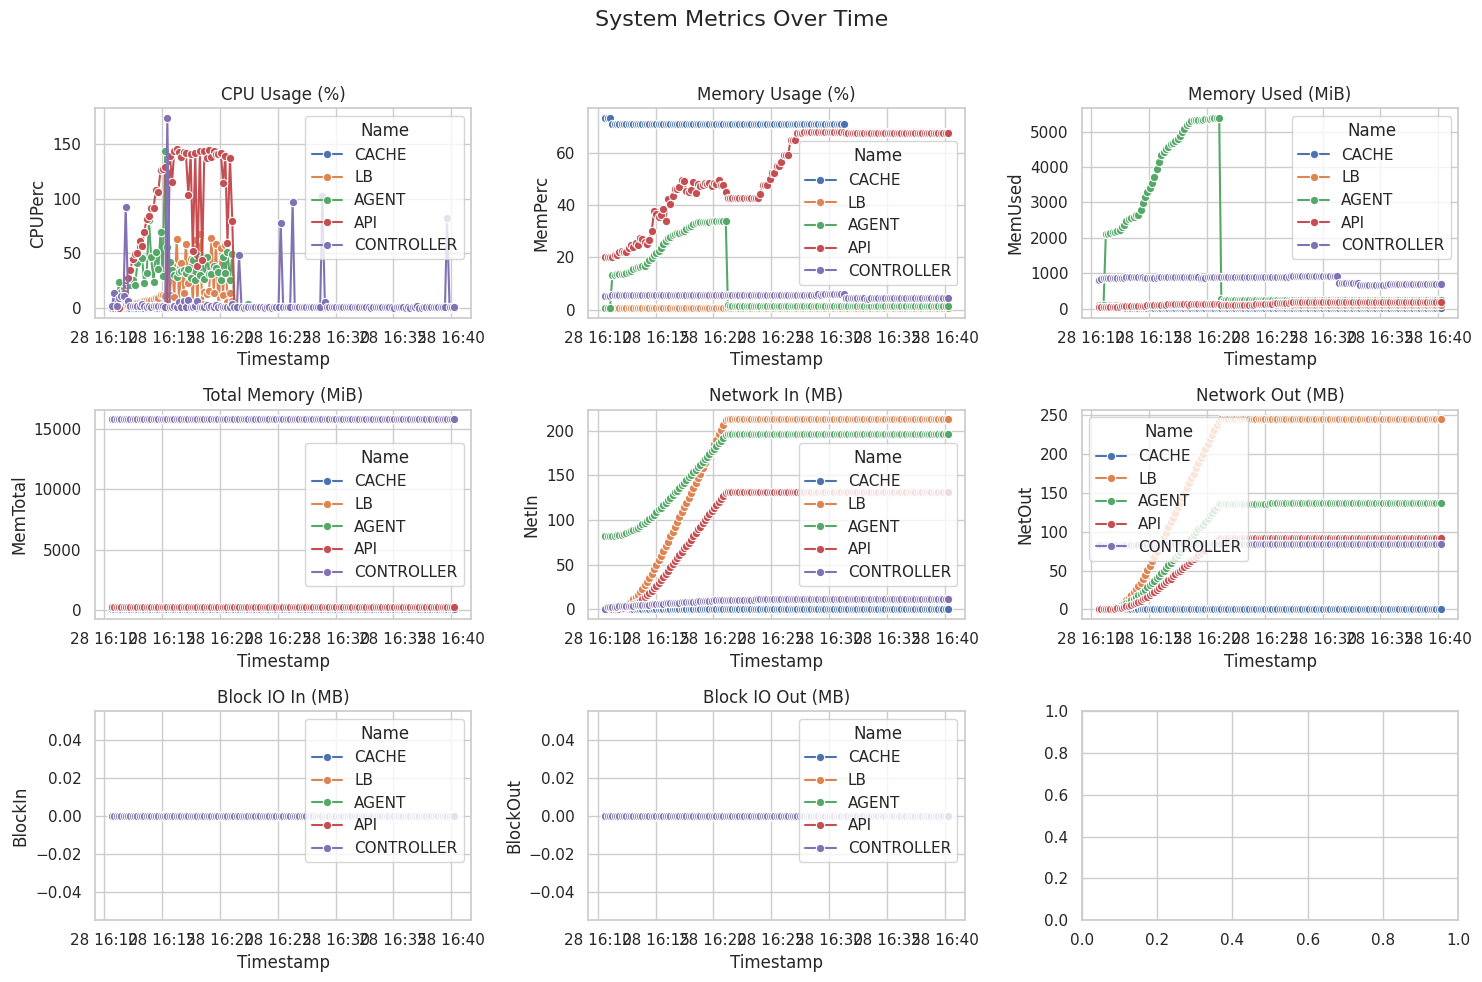

In [14]:
# Seaborn 스타일 적용
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle("System Metrics Over Time", fontsize=16)

# CPU 사용률
sns.lineplot(ax=axes[0, 0], data=df, x="Timestamp", y="CPUPerc", hue="Name", marker="o")
axes[0, 0].set_title("CPU Usage (%)")

# 메모리 사용률
sns.lineplot(ax=axes[0, 1], data=df, x="Timestamp", y="MemPerc", hue="Name", marker="o")
axes[0, 1].set_title("Memory Usage (%)")

# 실제 사용된 메모리
sns.lineplot(ax=axes[0, 2], data=df, x="Timestamp", y="MemUsed", hue="Name", marker="o")
axes[0, 2].set_title("Memory Used (MiB)")

# 총 메모리
sns.lineplot(ax=axes[1, 0], data=df, x="Timestamp", y="MemTotal", hue="Name", marker="o")
axes[1, 0].set_title("Total Memory (MiB)")

# 네트워크 In
sns.lineplot(ax=axes[1, 1], data=df, x="Timestamp", y="NetIn", hue="Name", marker="o")
axes[1, 1].set_title("Network In (MB)")

# 네트워크 Out
sns.lineplot(ax=axes[1, 2], data=df, x="Timestamp", y="NetOut", hue="Name", marker="o")
axes[1, 2].set_title("Network Out (MB)")

# 블록 I/O In
sns.lineplot(ax=axes[2, 0], data=df, x="Timestamp", y="BlockIn", hue="Name", marker="o")
axes[2, 0].set_title("Block IO In (MB)")

# 블록 I/O Out
sns.lineplot(ax=axes[2, 1], data=df, x="Timestamp", y="BlockOut", hue="Name", marker="o")
axes[2, 1].set_title("Block IO Out (MB)")

# 여백 조정
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [19]:
# Name 값이 LB, AGENT, API인 데이터만 필터링
df2_filtered = df[df['Name'].isin(['LB', 'AGENT', 'API'])]

# 필요한 컬럼만 선택
df2_filtered = df2_filtered[['Timestamp', 'Name', 'CPUPerc', 'MemPerc', 'MemUsed']]
df2_filtered.head(5)

,Timestamp,Name,CPUPerc,MemPerc,MemUsed
1,2025-02-28 16:10:40+09:00,LB,0.08,0.58,92.16
2,2025-02-28 16:10:40+09:00,AGENT,1.17,0.62,98.49
3,2025-02-28 16:10:40+09:00,API,0.10,20.04,51.30
6,2025-02-28 16:10:51+09:00,LB,0.11,0.58,92.16
7,2025-02-28 16:10:51+09:00,AGENT,0.25,0.62,98.45


In [21]:
# pdm add pyarrow
df2_filtered.to_parquet('01_numpy_dstats.parquet')